In [1]:
import HTSeq
import numpy as np

from price2.reference_annotation import ReferenceAnnotation
from price2.data_collector import DataCollector
from price2.ribo_seq_run import ribo_seq_runs_from_bams

from matplotlib import pyplot as plt

import numba as nb
#nb.set_num_threads(32)

In [2]:
gtf_file = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/input_data/homo_sapiens_chr_15.gtf'
fasta_file = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/input_data/homo_sapiens_chr_15.fasta'
bam_dir = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/input_data/bams/'

workingdir = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/workingdir'

In [3]:
ra = ReferenceAnnotation(gtf_file)

In [4]:
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_file))

In [5]:
runs = ribo_seq_runs_from_bams(bam_dir, workingdir, ra)

In [6]:
data_collector = DataCollector(bam_dir, ra, genome, runs)

In [7]:
reads_db_path = f'{workingdir}/reads.db'
transcript_read_counts_db_path = f'{workingdir}/tr_reads_counts.db'
data_collector.collect_mappings(reads_db_path, transcript_read_counts_db_path)


In [8]:
data_collector.make_rgrs(transcript_read_counts_db_path, genome)

In [9]:
loci_db_path = f'{workingdir}/loci.db'
data_collector.collect_loci(loci_db_path)

In [10]:
runs_db_path = f'{workingdir}/runs.db'
data_collector.collect_runs(runs_db_path)

In [11]:
################################
### restart interpreter here ###
################################

from price2.orf_activity_estimator import ORFActivityEstimator



In [12]:
workingdir = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/workingdir'
reads_db_path = f'{workingdir}/reads.db'
loci_db_path = f'{workingdir}/loci.db'
runs_db_path = f'{workingdir}/runs.db'

oae = ORFActivityEstimator(
    reads_db_path, 
    loci_db_path, 
    runs_db_path,
    )

In [13]:
oae.run_orf_deconvolution()

  0%|          | 0/200 [00:00<?, ?it/s]

In [22]:
oae.performance_df.to_csv(f'{workingdir}/performance.csv')

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
workingdir = '/projects/viro/maidhof/price2/orf_deconvolution_development/real_data/workingdir'
performance_df = pd.read_csv(f'{workingdir}/performance.csv', index_col=0)
performance_df.sort_values('overall_time')

,loc_id,overall_time,num_reads,cg_time,eg_time,rsa_time,opt_time,num_cgs,num_egs,num_orfs,num_transcripts,num_iterations
77,loc_1543,0.157574,61,0.001357,0.006779,0.043737,0.075795,1,19,0,1,14
143,loc_19,0.238776,102,0.001391,0.031061,0.077658,0.027272,1,19,0,1,16
20,loc_1332,0.301833,74,0.002710,0.017275,0.063261,0.076442,3,109,2,1,23
42,loc_706,0.374854,511,0.007498,0.017488,0.179167,0.031477,4,154,3,1,67
49,loc_506,0.701521,134,0.019523,0.042053,0.136212,0.156491,6,236,4,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...
194,loc_233,201.452346,15551,2.160877,10.509439,20.801863,138.453178,382,16592,300,7,1013
195,loc_390,201.686572,77963,0.955140,4.925415,92.371355,67.254999,256,10890,190,11,1333
197,loc_1183,225.437895,7908,57.959048,37.639639,15.992054,92.847422,380,16694,294,1,1184
199,loc_135,266.601666,3037,75.428396,62.951594,6.714642,90.732670,448,19640,334,2,886


In [16]:
performance_df.sort_values('overall_time')

,loc_id,overall_time,num_reads,cg_time,eg_time,rsa_time,opt_time,num_cgs,num_egs,num_orfs,num_transcripts,num_iterations
77,loc_1543,0.157574,61,0.001357,0.006779,0.043737,0.075795,1,19,0,1,14
143,loc_19,0.238776,102,0.001391,0.031061,0.077658,0.027272,1,19,0,1,16
20,loc_1332,0.301833,74,0.002710,0.017275,0.063261,0.076442,3,109,2,1,23
42,loc_706,0.374854,511,0.007498,0.017488,0.179167,0.031477,4,154,3,1,67
49,loc_506,0.701521,134,0.019523,0.042053,0.136212,0.156491,6,236,4,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...
194,loc_233,201.452346,15551,2.160877,10.509439,20.801863,138.453178,382,16592,300,7,1013
195,loc_390,201.686572,77963,0.955140,4.925415,92.371355,67.254999,256,10890,190,11,1333
197,loc_1183,225.437895,7908,57.959048,37.639639,15.992054,92.847422,380,16694,294,1,1184
199,loc_135,266.601666,3037,75.428396,62.951594,6.714642,90.732670,448,19640,334,2,886


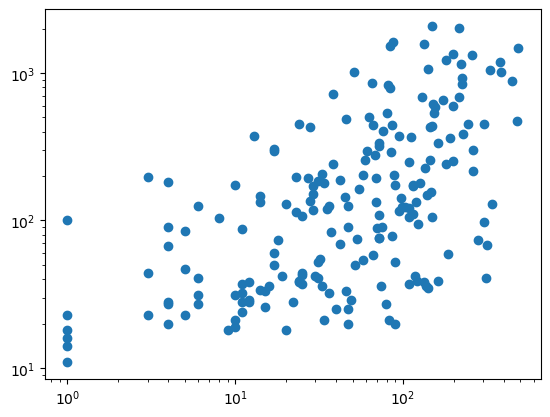

In [17]:
plt.scatter(performance_df['num_cgs'], performance_df['num_iterations'])
plt.yscale('log')
plt.xscale('log')

In [18]:
performance_old_df = pd.read_csv(f'{workingdir}/performance_without_filter.csv', index_col=0)
performance_old_df

,loc_id,overall_time,num_reads,cg_time,eg_time,rsa_time,opt_time,num_cgs,num_egs,num_orfs,num_transcripts,num_iterations
0,loc_768,5.798522,1,0.003358,0.542375,0.014558,4.532742,3,109,2,1,40
1,loc_751,6.078357,9,0.009906,0.774431,0.019554,4.466630,9,371,6,1,0
2,loc_731,6.159916,1,0.008161,0.672034,0.015999,4.568731,9,371,7,1,0
3,loc_56,6.155035,1,0.007065,0.580964,0.014368,4.678021,8,334,6,1,0
4,loc_762,0.040072,0,0.000465,0.002904,0.015411,0.002272,1,19,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
195,loc_1271,310.881360,5017,6.961878,23.437729,13.354612,223.823497,341,14733,268,15,2579
196,loc_663,715.288656,7284,6.698500,29.025911,8.886501,601.987738,450,19428,381,22,4795
197,loc_737,866.577441,15508,1.127730,3.757565,8.617452,809.510166,365,15305,261,24,9065
198,loc_628,858.827453,6974,41.317331,84.763357,17.792479,647.601933,564,24444,423,27,4093


In [19]:
# get rows of performance_df and performance_old_df where loc_id is in both
common_loc_ids = set(performance_df['loc_id']).intersection(performance_old_df['loc_id'])
performance_df_common = performance_df[performance_df['loc_id'].isin(common_loc_ids)]
performance_old_df_common = performance_old_df[performance_old_df['loc_id'].isin(common_loc_ids)]


In [20]:
performance_df.sort_values('overall_time', ascending=True)

,loc_id,overall_time,num_reads,cg_time,eg_time,rsa_time,opt_time,num_cgs,num_egs,num_orfs,num_transcripts,num_iterations
77,loc_1543,0.157574,61,0.001357,0.006779,0.043737,0.075795,1,19,0,1,14
143,loc_19,0.238776,102,0.001391,0.031061,0.077658,0.027272,1,19,0,1,16
20,loc_1332,0.301833,74,0.002710,0.017275,0.063261,0.076442,3,109,2,1,23
42,loc_706,0.374854,511,0.007498,0.017488,0.179167,0.031477,4,154,3,1,67
49,loc_506,0.701521,134,0.019523,0.042053,0.136212,0.156491,6,236,4,1,31
...,...,...,...,...,...,...,...,...,...,...,...,...
194,loc_233,201.452346,15551,2.160877,10.509439,20.801863,138.453178,382,16592,300,7,1013
195,loc_390,201.686572,77963,0.955140,4.925415,92.371355,67.254999,256,10890,190,11,1333
197,loc_1183,225.437895,7908,57.959048,37.639639,15.992054,92.847422,380,16694,294,1,1184
199,loc_135,266.601666,3037,75.428396,62.951594,6.714642,90.732670,448,19640,334,2,886


In [21]:
import pandas as pd
for id, loc in oae.loci_dict.items():
    df = pd.DataFrame(loc)
    fig, axs = plt.subplots(len(df), 1, figsize=(5, 3*len(df)))
    if len(df)>1:
        for i, ax in enumerate(axs):
            ax.hist(df.iloc[i], bins=100, alpha=.3, range=(0,1))
            ax.title.set_text(df.iloc[i].name)
    fig.tight_layout()

AttributeError: 'ORFActivityEstimator' object has no attribute 'loci_dict'

In [ ]:
loc = list(oae.loci.values())[103]

loc.opt_result

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: -3341.1454611142362
        x: [-2.240e+01 -1.847e+01 ... -1.860e+01 -7.059e+00]
      nit: 2511
      jac: [ 6.073e-06  1.338e-05 ...  7.495e-06  4.531e-04]
     nfev: 2690
     njev: 2690
 hess_inv: <570x570 LbfgsInvHessProduct with dtype=float64>